# Phase1: Data collection

## Data collection code
We used the same code for every year separately. they were executed using diffrent tokens by diffrent students.

The actual tokens were written instead of the word "Token" in the 7th line but due to security reasons they got replaced in the code.

Later on the files collected by each student were merged together in one file.


* 2020


In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2020-01-01', '2020-03-31'),
    ('2020-04-01', '2020-06-30'),
    ('2020-07-01', '2020-09-30'),
    ('2020-10-01', '2020-12-31')
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2020_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")


🔍 Fetching top 250 repos from 2020-01-01 to 2020-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2020-04-01 to 2020-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2020-07-01 to 2020-09-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2020-10-01 to 2020-12-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2020_quarters.csv


* 2021

In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2021-01-01', '2021-03-31'),
    ('2021-04-01', '2021-06-30'),
    ('2021-07-01', '2021-09-30'),
    ('2021-10-01', '2021-12-31')
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2021_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")

🔍 Fetching top 250 repos from 2021-01-01 to 2021-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2021-04-01 to 2021-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2021-07-01 to 2021-09-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2021-10-01 to 2021-12-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2021_quarters.csv


* 2022

In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2022-01-01', '2022-03-31'),
    ('2022-04-01', '2022-06-30'),
    ('2022-07-01', '2022-09-30'),
    ('2022-10-01', '2022-12-31')
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2022_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")

🔍 Fetching top 250 repos from 2022-01-01 to 2022-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2022-04-01 to 2022-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2022-07-01 to 2022-09-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2022-10-01 to 2022-12-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2022_quarters.csv


* 2023

In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2023-01-01', '2023-03-31'),
    ('2023-04-01', '2023-06-30'),
    ('2023-07-01', '2023-09-30'),
    ('2023-10-01', '2023-12-31')
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2023_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")

🔍 Fetching top 250 repos from 2023-01-01 to 2023-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2023-04-01 to 2023-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2023-07-01 to 2023-09-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2023-10-01 to 2023-12-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2023_quarters.csv


* 2024

In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2024-01-01', '2024-03-31'),
    ('2024-04-01', '2024-06-30'),
    ('2024-07-01', '2024-09-30'),
    ('2024-10-01', '2024-12-31')
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2024_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")

🔍 Fetching top 250 repos from 2024-01-01 to 2024-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2024-04-01 to 2024-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2024-07-01 to 2024-09-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2024-10-01 to 2024-12-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2024_quarters.csv


* 2025

In [ ]:
import requests
import pandas as pd
import time
import random
import re

# ==== CONFIG ====
GITHUB_TOKEN = 'Token'  # حطو حقكم
HEADERS = {
    "Authorization": f"token {GITHUB_TOKEN}",
    "Accept": "application/vnd.github+json",
    "X-GitHub-Api-Version": "2022-11-28",
    "User-Agent": "Data-Science-Project-KSUM"
}

QUERY = 'AI OR artificial-intelligence OR machine-learning OR generative-ai'
PER_PAGE = 100
REPOS_PER_QUARTER = 250  # target per quarter
QUARTERS = [
    ('2025-01-01', '2025-03-31'),
    ('2025-04-01', '2025-06-30'),
    ('2025-07-01', '2025-09-23'),
]#غيرو السنه للسنه حقتكم

# ==== FUNCTIONS ====

def get_repo_details(full_name):
    """Fetch detailed repo info: languages, topics, license, contributors"""
    repo_details = {'languages': {}, 'topics': [], 'license': None, 'contributors_count': 0}

    # Languages
    languages_url = f"https://api.github.com/repos/{full_name}/languages"
    languages_res = requests.get(languages_url, headers=HEADERS)
    if languages_res.status_code == 200:
        repo_details['languages'] = languages_res.json()

    # Topics
    topics_url = f"https://api.github.com/repos/{full_name}/topics"
    topics_headers = HEADERS.copy()
    topics_headers['Accept'] = 'application/vnd.github.mercy-preview+json'
    topics_res = requests.get(topics_url, headers=topics_headers)
    if topics_res.status_code == 200:
        repo_details['topics'] = topics_res.json().get('names', [])

    # License
    repo_url = f"https://api.github.com/repos/{full_name}"
    repo_res = requests.get(repo_url, headers=HEADERS)
    if repo_res.status_code == 200:
        repo_data = repo_res.json()
        if 'license' in repo_data and repo_data['license']:
            repo_details['license'] = repo_data['license'].get('spdx_id')

    # Contributors count
    contributors_url = f"https://api.github.com/repos/{full_name}/contributors?per_page=1"
    contributors_res = requests.get(contributors_url, headers=HEADERS)
    if contributors_res.status_code == 200:
        if 'Link' in contributors_res.headers and 'last' in contributors_res.headers['Link']:
            last_page_url = re.search(r'<(.+)>; rel="last"', contributors_res.headers['Link']).group(1)
            last_page_number = int(re.search(r'page=(\d+)', last_page_url).group(1))
            repo_details['contributors_count'] = last_page_number
        else:
            repo_details['contributors_count'] = len(contributors_res.json())

    return repo_details

def fetch_top_repositories(query, start_date, end_date, per_page=30, max_repos=250):
    """Fetch repositories sorted by stars in a given date range"""
    repos = []
    page = 1
    while len(repos) < max_repos:
        search_query = f'{query} created:{start_date}..{end_date}'
        url = "https://api.github.com/search/repositories"
        params = {
            'q': search_query,
            'sort': 'stars',
            'order': 'desc',
            'per_page': per_page,
            'page': page
        }
        response = requests.get(url, headers=HEADERS, params=params)
        if response.status_code != 200:
            print("Error:", response.status_code, response.text)
            break

        items = response.json().get('items', [])
        if not items:
            break

        repos.extend(items)
        page += 1
        time.sleep(1)

    return repos[:max_repos]

# ==== MAIN EXECUTION ====
if __name__ == '__main__':
    all_final_data = []

    for start_date, end_date in QUARTERS:
        print(f"🔍 Fetching top {REPOS_PER_QUARTER} repos from {start_date} to {end_date}...")
        quarter_repos = fetch_top_repositories(QUERY, start_date, end_date, PER_PAGE, REPOS_PER_QUARTER)

        print(f"📦 Collecting detailed info for {len(quarter_repos)} repos...")
        for item in quarter_repos:
            owner = item.get('owner', {}).get('login')
            name = item.get('name')
            full_name = f"{owner}/{name}"

            repo_details = get_repo_details(full_name)

            repo_info = {
                'name': name,
                'owner': owner,
                'url': item.get('html_url'),
                'description': item.get('description'),
                'stars': item.get('stargazers_count'),
                'forks': item.get('forks_count'),
                'created_at': item.get('created_at'),
                'pushed_at': item.get('pushed_at'),
                'primary_language': item.get('language'),
                'all_languages_bytes': repo_details['languages'],
                'topics': ", ".join(repo_details['topics']),
                'contributors_count': repo_details['contributors_count']
            }

            all_final_data.append(repo_info)
            time.sleep(0.5)

    df = pd.DataFrame(all_final_data)
    output_filename = "github_ai_repos_2025_quarters.csv"#سموه باسم السنه حقتكم
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n✅ Completed! Saved {len(df)} repositories to {output_filename}")

🔍 Fetching top 250 repos from 2025-01-01 to 2025-03-31...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2025-04-01 to 2025-06-30...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...
🔍 Fetching top 250 repos from 2025-07-01 to 2025-09-23...
Error: 401 {
  "message": "Bad credentials",
  "documentation_url": "https://docs.github.com/rest",
  "status": "401"
}
📦 Collecting detailed info for 0 repos...

✅ Completed! Saved 0 repositories to github_ai_repos_2025_quarters.csv


# Phase2: Data Processing and EDA

## Dataset information preview

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import warnings
from pandas.errors import DtypeWarning

# Ignore DtypeWarning
warnings.filterwarnings('ignore', category=DtypeWarning)

# Columns you want to keep
columns_to_keep = [
    "name", "owner", "url", "description", "stars", "forks",
    "created_at", "pushed_at", "primary_language", "all_languages_bytes",
    "topics", "contributors_count"
]

# Load the dataset and select specified columns
df = pd.read_csv('collectedData.csv')[columns_to_keep]


# === BASIC INFO ===
attribute_informations = pd.DataFrame({
    'AttributeName' : df.columns,
    'DataType' : df.dtypes.values
})

print(f"Number of attributes: {len(df.columns)}")
print(f"Number of objects: {len(df)}")
print("\nAttributes and Their Types:")
print(attribute_informations)

# Preview
df.head()

## Dataset quality check

### Check if data is enough (sample size adequacy)

In [ ]:
# We'll compute the required sample size for 95% confidence, 5% margin of error.
# Formula: n = (Z^2 * p * (1-p)) / e^2
# Assuming p = 0.5 (maximum variability) and Z = 1.96 for 95% confidence.

Z = 1.96
p = 0.5
e = 0.05

required_n = (Z**2 * p * (1 - p)) / (e**2)
collected_n = len(df)

print(f"Required sample size: {required_n:.0f}")
print(f"Collected observations: {collected_n}")
if collected_n >= required_n:
    print("The collected data size is statistically sufficient.")
else:
    print("The dataset may be smaller than the recommended sample size.")

Required sample size: 384
Collected observations: 5751
The collected data size is statistically sufficient.


### Check for duplicates and missing values

In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Clean dataset
df_cleaned = df.dropna(subset=['primary_language']).drop_duplicates()

# Define numeric columns for later preprocessing
numeric_cols = ['stars', 'forks', 'contributors_count']

print("\nOriginal DataFrame shape:", df.shape)
print("Cleaned DataFrame shape:", df_cleaned.shape)

df_cleaned.to_csv('CleanedDataset.csv', index=False)


Missing values per column:
name                      0
owner                     0
url                       0
description             115
stars                     3
forks                     4
created_at                3
pushed_at                 5
primary_language        642
all_languages_bytes       5
topics                 1099
contributors_count        5
dtype: int64

Number of duplicate rows:
0

Original DataFrame shape: (5751, 12)
Cleaned DataFrame shape: (5109, 12)


After checking our dataset quality we only removed rows that miss primary language attribute.

## Data preprocessing

### Transforming

In [ ]:
import numpy as np

# Convert 'stars', 'forks' and 'contributors_count' columns to numeric, coercing errors
df_cleaned['stars'] = pd.to_numeric(df_cleaned['stars'], errors='coerce')
df_cleaned['forks'] = pd.to_numeric(df_cleaned['forks'], errors='coerce')
df_cleaned['contributors_count'] = pd.to_numeric(df_cleaned['contributors_count'], errors='coerce')

# Fill missing numeric values with median
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Handle outliers
df_cleaned['stars_log'] = np.log1p(df_cleaned['stars'])  # log(1 + x) to handle 0
df_cleaned['forks_log'] = np.log1p(df_cleaned['forks'])

print("\nStatistical summary for numeric columns:")
print(df_cleaned.describe())

print("\nTop 10 most common programming languages:")
print(df_cleaned['primary_language'].value_counts().head(10))


Statistical summary for numeric columns:
               stars         forks  contributors_count    stars_log  \
count    5109.000000   5109.000000         5109.000000  5109.000000   
mean     3610.806029    521.493247            0.997455     6.841050   
std     10327.308558   2242.317771            0.050384     1.431334   
min        94.000000      0.000000            0.000000     4.553877   
25%       330.000000     43.000000            1.000000     5.802118   
50%       700.000000     98.000000            1.000000     6.552508   
75%      1985.000000    275.000000            1.000000     7.593878   
max    178659.000000  60974.000000            1.000000    12.093240   

         forks_log  
count  5109.000000  
mean      4.813219  
std       1.463880  
min       0.000000  
25%       3.784190  
50%       4.595120  
75%       5.620401  
max      11.018219  

Top 10 most common programming languages:
primary_language
Python              2254
TypeScript           726
Jupyter Notebook   

### Check data consistency and data types

In [ ]:
# Check for invalid (non-numeric) entries replaced with NaN
invalid_counts = df_cleaned[numeric_cols].isna().sum()
print("Invalid numeric entries (converted to NaN):\n", invalid_counts)

# Optional: fill missing numeric values with median
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Confirm dtypes
df_cleaned.dtypes

Invalid numeric entries (converted to NaN):
 stars                 0
forks                 0
contributors_count    0
dtype: int64


,0
name,object
owner,object
url,object
description,object
stars,float64
forks,float64
created_at,object
pushed_at,object
primary_language,object
all_languages_bytes,object


Checking dates format

In [ ]:
df_cleaned["created_at"] = pd.to_datetime(df_cleaned["created_at"], errors='coerce')
df_cleaned["pushed_at"] = pd.to_datetime(df_cleaned["pushed_at"], errors='coerce')

df_cleaned.head(3)

,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count,stars_log,forks_log
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213.0,4564.0,2020-01-23 18:35:18+00:00,2025-09-25 00:42:02+00:00,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1.0,10.601970,8.426174
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016.0,3470.0,2020-03-14 11:46:39+00:00,2024-09-24 11:24:36+00:00,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1.0,10.240567,8.152198
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807.0,9161.0,2020-02-28 19:26:47+00:00,2024-08-16 14:38:24+00:00,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1.0,10.077777,9.122820


## EDA - Visualizations

### Distribution of repository stars

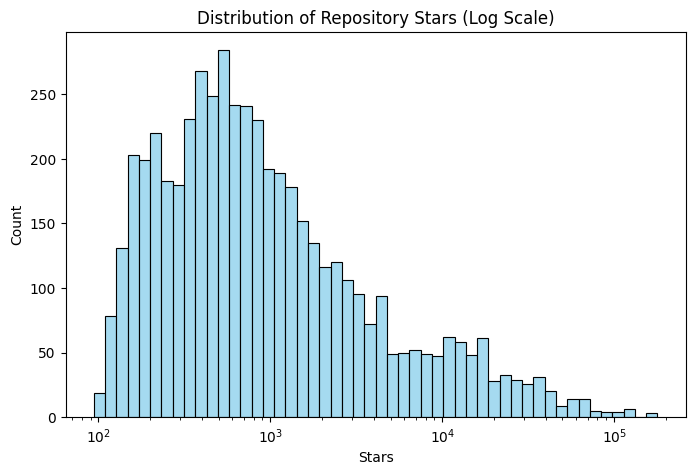

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned['stars'].dropna(), bins=50, log_scale=True, color='skyblue')
plt.title("Distribution of Repository Stars (Log Scale)")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

Top 10 most common topics:
 machine-learning: 1378
ai: 778
 deep-learning: 772
 python: 743
 ai: 671
 llm: 637
 openai: 430
 pytorch: 415
 artificial-intelligence: 306
 chatgpt: 254


/tmp/ipython-input-2026645062.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_topics_df, x='topic', y='count', palette='viridis')


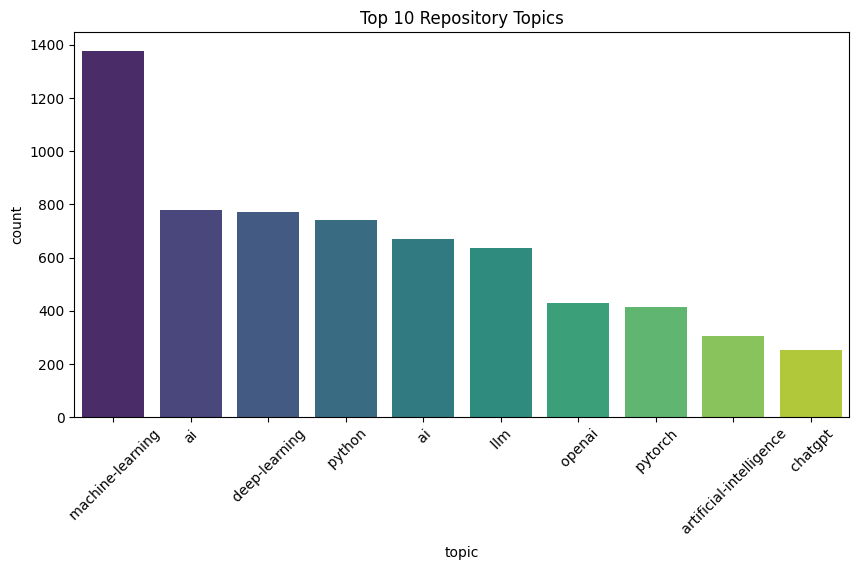

In [ ]:
from collections import Counter

# Drop NaN and split topics (assuming topics are stored as comma-separated strings)
all_topics = df_cleaned['topics'].dropna().str.split(',').sum()
topic_counts = Counter(all_topics)

# Most common topics
top_topics = topic_counts.most_common(10)
print("Top 10 most common topics:")
for topic, count in top_topics:
    print(f"{topic}: {count}")

# Optional: Bar plot
top_topics_df = pd.DataFrame(top_topics, columns=['topic', 'count'])
plt.figure(figsize=(10,5))
sns.barplot(data=top_topics_df, x='topic', y='count', palette='viridis')
plt.xticks(rotation=45)
plt.title("Top 10 Repository Topics")
plt.show()


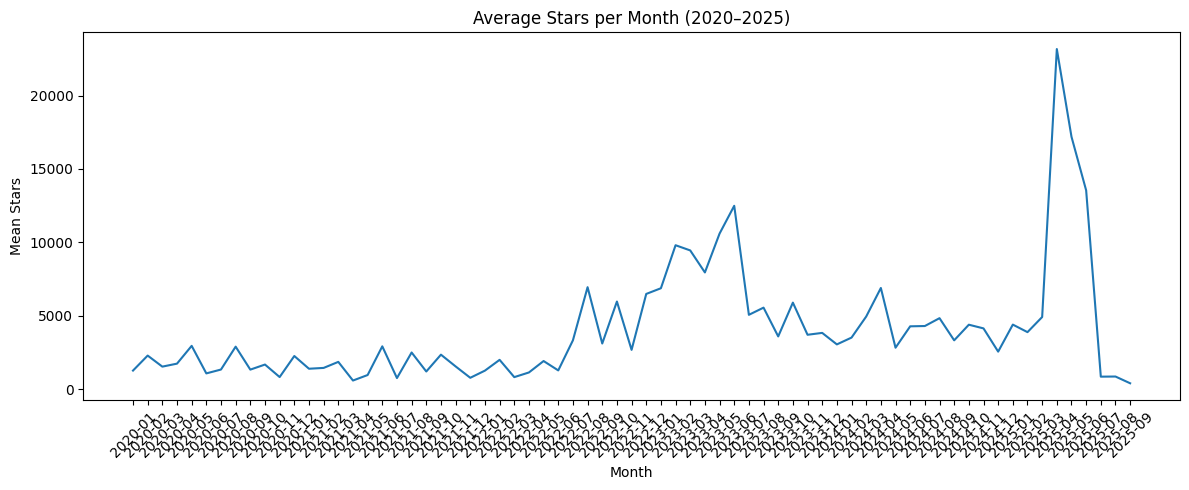

In [ ]:
# Group by month directly without adding a column
monthly_stars = (
    df_cleaned.groupby(df_cleaned["created_at"].dt.to_period("M"))["stars"]
      .mean()
      .reset_index()
)

monthly_stars["created_at"] = monthly_stars["created_at"].astype(str)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_stars, x="created_at", y="stars")
plt.xticks(rotation=45)
plt.title("Average Stars per Month (2020–2025)")
plt.xlabel("Month")
plt.ylabel("Mean Stars")
plt.tight_layout()
plt.show()

### Top programming languages used

Top Primary langueges used

In [ ]:
# Replace "Jupyter Notebook" with "Python" in the primary_language column
df_cleaned['primary_language'] = df_cleaned['primary_language'].replace('Jupyter Notebook', 'Python')

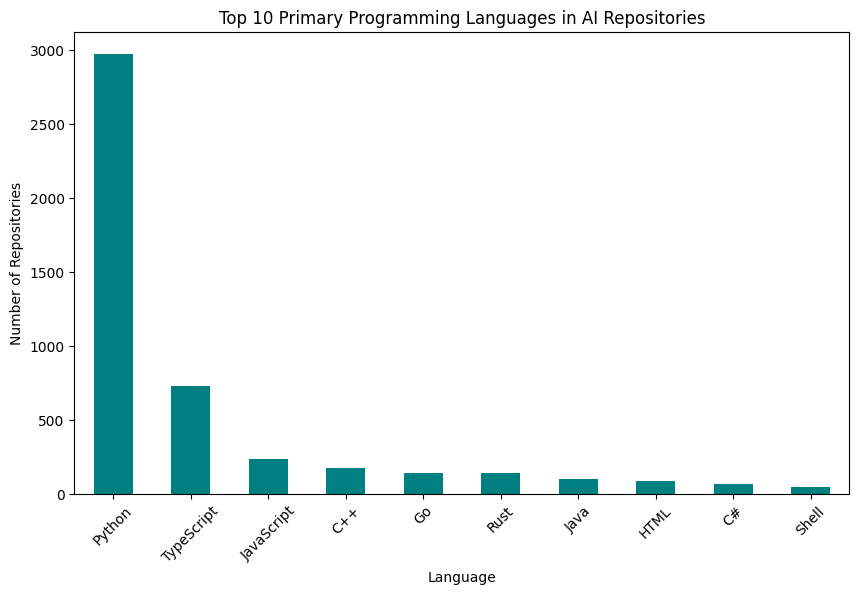

In [ ]:
plt.figure(figsize=(10,6))
df_cleaned['primary_language'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title("Top 10 Primary Programming Languages in AI Repositories")
plt.xlabel("Language")
plt.ylabel("Number of Repositories")
plt.xticks(rotation=45)
plt.show()

Top all languages used

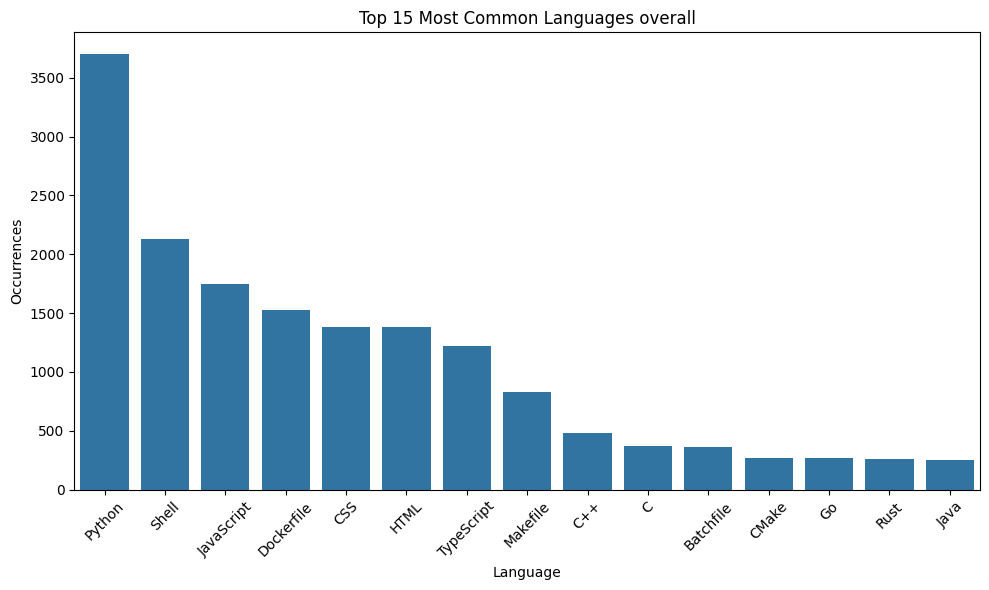

In [ ]:
from collections import Counter
import ast

lang_counter = Counter()

for entry in df_cleaned["all_languages_bytes"].dropna():
    try:
        langs = ast.literal_eval(entry)
        if isinstance(langs, dict):
          # Merge Jupyter Notebook into Python
            langs = {
                ("Python" if lang == "Jupyter Notebook" else lang): count
                for lang, count in langs.items()
            }
            lang_counter.update(langs.keys())
    except:
        continue

lang_freq = pd.DataFrame(lang_counter.items(), columns=["language", "count"]).sort_values(by="count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=lang_freq.head(15), x="language", y="count")
plt.xticks(rotation=45)
plt.title("Top 15 Most Common Languages overall")
plt.xlabel("Language")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

Top languages used when python was the primary language

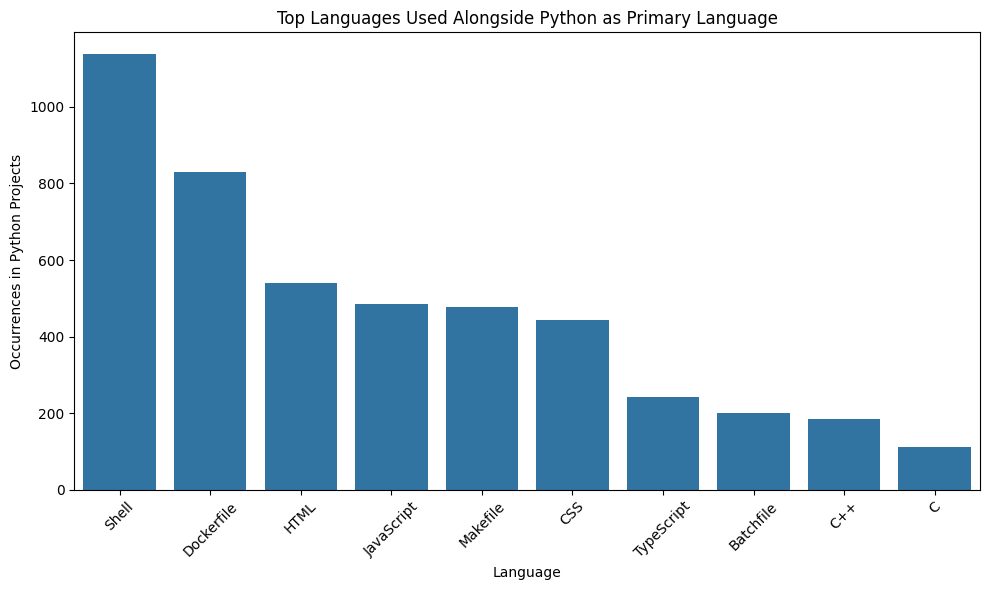

In [ ]:
import ast
from collections import Counter

# Filter only repositories where Python is the primary language
python_repos = df_cleaned[df_cleaned["primary_language"].str.lower() == "python"]

# Count co-occurring languages in the 'all_languages_bytes' column
lang_counter = Counter()

for entry in python_repos["all_languages_bytes"].dropna():
    try:
        langs = ast.literal_eval(entry)
        if isinstance(langs, dict):
          # Merge Jupyter Notebook into Python
            langs = {
                ("Python" if lang == "Jupyter Notebook" else lang): count
                for lang, count in langs.items()
            }
            lang_counter.update(langs.keys())
    except:
        continue

# Remove 'Python' itself to see other associated languages
if "Python" in lang_counter:
    del lang_counter["Python"]

lang_freq_py = (
    pd.DataFrame(lang_counter.items(), columns=["language", "count"])
    .sort_values(by="count", ascending=False)
)

plt.figure(figsize=(10,6))
sns.barplot(data=lang_freq_py.head(10), x="language", y="count")
plt.title("Top Languages Used Alongside Python as Primary Language")
plt.xticks(rotation=45)
plt.xlabel("Language")
plt.ylabel("Occurrences in Python Projects")
plt.tight_layout()
plt.show()

### Repositories created over time

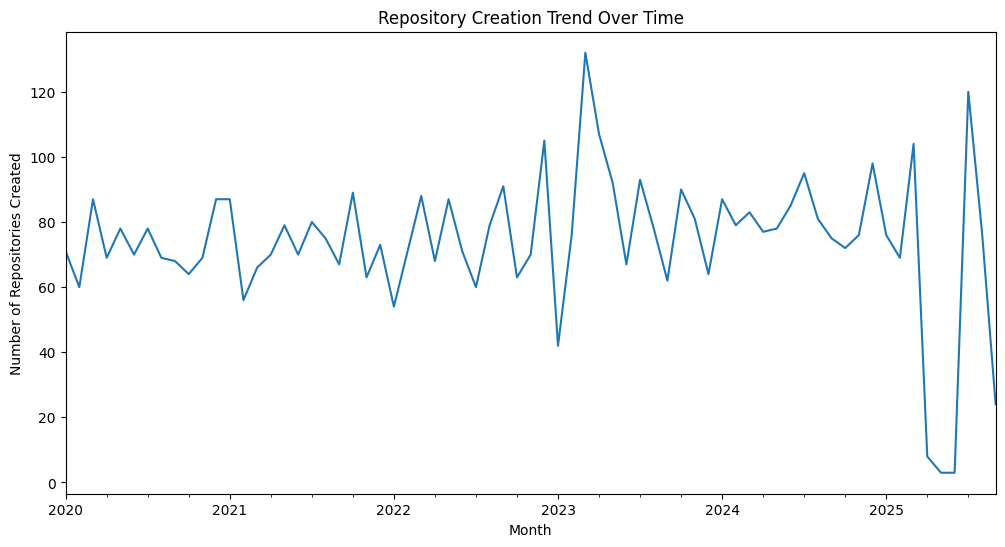

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning)
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'], errors='coerce')
plt.figure(figsize=(12,6))
df_cleaned['created_at'].dt.to_period("M").value_counts().sort_index().plot(kind='line')
plt.title("Repository Creation Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Repositories Created")
plt.show()

### Stars vs Forks scatter plot

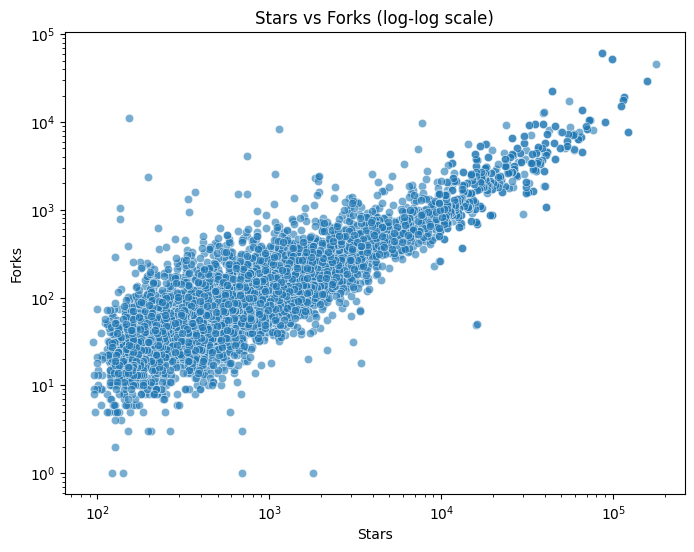

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned.dropna(subset=['stars', 'forks']), x='stars', y='forks', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title("Stars vs Forks (log-log scale)")
plt.xlabel("Stars")
plt.ylabel("Forks")
plt.show()

In [ ]:
# Compute repository age in days
df_cleaned["repo_age_days"] = (df_cleaned["pushed_at"] - df_cleaned["created_at"]).dt.days

# Optional: also compute in years
df_cleaned["repo_age_years"] = df_cleaned["repo_age_days"] / 365

# Inspect
df_cleaned[["name", "repo_age_days", "stars", "forks"]].head()


,name,repo_age_days,stars,forks
0,DeepSpeed,2071.0,40213.0,4564.0
1,EasyOCR,1654.0,28016.0,3470.0
2,fastbook,1630.0,23807.0,9161.0
3,serve,1865.0,21746.0,2236.0
5,datasets,2008.0,20687.0,2953.0


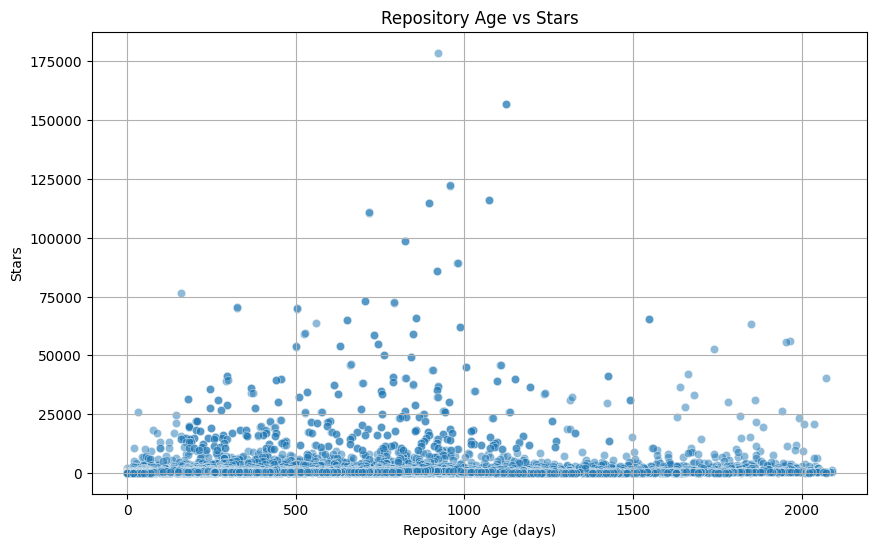

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    x="repo_age_days",
    y="stars",
    data=df_cleaned,
    alpha=0.5
)
plt.title("Repository Age vs Stars")
plt.xlabel("Repository Age (days)")
plt.ylabel("Stars")
plt.grid(True)
plt.show()


In [ ]:
correlation = df_cleaned["repo_age_days"].corr(df_cleaned["stars"])
print(f"Correlation between repository age and stars: {correlation:.3f}")


Correlation between repository age and stars: 0.023


# Phase3: Modeling

## Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


In [ ]:
df = pd.read_csv("CleanedDataset.csv")

print(" Dataset Loaded Successfully!")
df.head()


 Dataset Loaded Successfully!


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [ ]:
import pandas as pd
df = pd.read_csv("CleanedDataset.csv")
print(df.shape)
print(df.columns.tolist())
df.head()


(5109, 12)
['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


,name,owner,url,description,stars,forks,created_at,pushed_at,primary_language,all_languages_bytes,topics,contributors_count
0,DeepSpeed,deepspeedai,https://github.com/deepspeedai/DeepSpeed,DeepSpeed is a deep learning optimization libr...,40213,4564,2020-01-23T18:35:18Z,2025-09-25T00:42:02Z,Python,"{'Python': 5912469, 'C++': 1505585, 'Cuda': 71...","deep-learning, pytorch, gpu, machine-learning,...",1
1,EasyOCR,JaidedAI,https://github.com/JaidedAI/EasyOCR,Ready-to-use OCR with 80+ supported languages ...,28016,3470,2020-03-14T11:46:39Z,2024-09-24T11:24:36Z,Python,"{'Python': 633819, 'C++': 112732, 'Cuda': 5825...","ocr, deep-learning, crnn, pytorch, lstm, machi...",1
2,fastbook,fastai,https://github.com/fastai/fastbook,"The fastai book, published as Jupyter Notebooks",23807,9161,2020-02-28T19:26:47Z,2024-08-16T14:38:24Z,Jupyter Notebook,"{'Jupyter Notebook': 8892620, 'Python': 5190}","notebooks, fastai, deep-learning, machine-lear...",1
3,serve,jina-ai,https://github.com/jina-ai/serve,☁️ Build multimodal AI applications with cloud...,21746,2236,2020-02-13T17:04:44Z,2025-03-24T13:59:54Z,Python,"{'Python': 2806034, 'Go': 46933, 'Shell': 2394...","neural-search, cloud-native, deep-learning, ma...",1
4,datasets,huggingface,https://github.com/huggingface/datasets,🤗 The largest hub of ready-to-use datasets for...,20687,2953,2020-03-26T09:23:22Z,2025-09-24T20:54:18Z,Python,"{'Python': 3005121, 'Makefile': 465}","nlp, datasets, pytorch, tensorflow, pandas, nu...",1


In [ ]:
import re

def normalize(col):
    col = col.strip().lower()
    col = re.sub(r'[\s\-]+', '_', col)      # مسافات/شرطات -> _
    col = re.sub(r'[^0-9a-zA-Z_]+', '', col)
    return col

df.columns = [normalize(c) for c in df.columns]
print(df.columns.tolist())


['name', 'owner', 'url', 'description', 'stars', 'forks', 'created_at', 'pushed_at', 'primary_language', 'all_languages_bytes', 'topics', 'contributors_count']


In [ ]:
# دوال مساعدة لاختيار أول عمود يطابق أي مرشح
def pick(colnames, candidates):
    for c in colnames:
        for cand in candidates:
            if cand in c:
                return c
    return None

cols = df.columns.tolist()

stars_col  = pick(cols, ["stargazers_count","stars","stargazers"])
forks_col  = pick(cols, ["forks_count","forks"])
lang_col   = pick(cols, ["primary_language","language","lang"])
year_col   = pick(cols, ["created_year","year"])  # قد ما يكون موجود

created_at_col = pick(cols, ["created_at","created_date","created"])  # بديل لاستخراج السنة إن ما وُجد year

print("stars_col :", stars_col)
print("forks_col :", forks_col)
print("lang_col  :", lang_col)
print("year_col  :", year_col)
print("created_at_col :", created_at_col)


stars_col : stars
forks_col : forks
lang_col  : primary_language
year_col  : None
created_at_col : created_at


In [ ]:
import numpy as np

if (year_col is None) and (created_at_col is not None):
    df['created_year'] = pd.to_datetime(df[created_at_col], errors='coerce').dt.year
    year_col = 'created_year'

# تحويل أعمدة النجوم/الفورك لأرقام لو كانت نصوص
for c in [stars_col, forks_col]:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [ ]:
required = [stars_col, forks_col, year_col, lang_col]
if any(x is None for x in required):
    missing = [n for n,x in zip(["stars","forks","year","language"], required) if x is None]
    raise ValueError(f"Couldn't find needed columns: {missing}. Please show df.columns so we map them manually.")

# تخلص من الصفوف الناقصة
use_df = df[[stars_col, forks_col, year_col, lang_col]].dropna().copy()
use_df.head()


,stars,forks,created_year,primary_language
0,40213.0,4564.0,2020.0,Python
1,28016.0,3470.0,2020.0,Python
2,23807.0,9161.0,2020.0,Jupyter Notebook
3,21746.0,2236.0,2020.0,Python
4,20687.0,2953.0,2020.0,Python


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Encode language
enc = LabelEncoder()
use_df['language_encoded'] = enc.fit_transform(use_df[lang_col].fillna('Unknown').astype(str))

# Features + scaling
X = use_df[[stars_col, forks_col, year_col, 'language_encoded']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


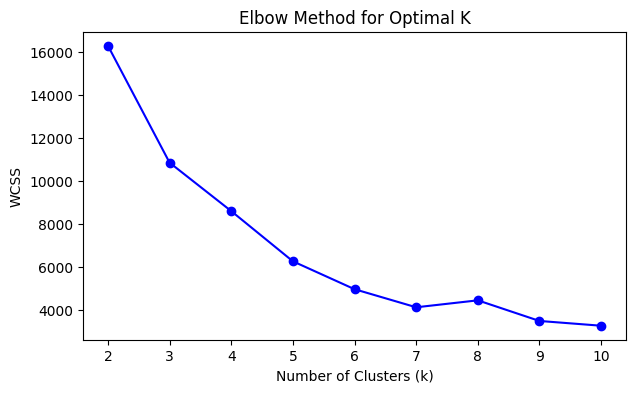

In [ ]:
wcss = []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, wcss, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()


Silhouette (KMeans): 0.383


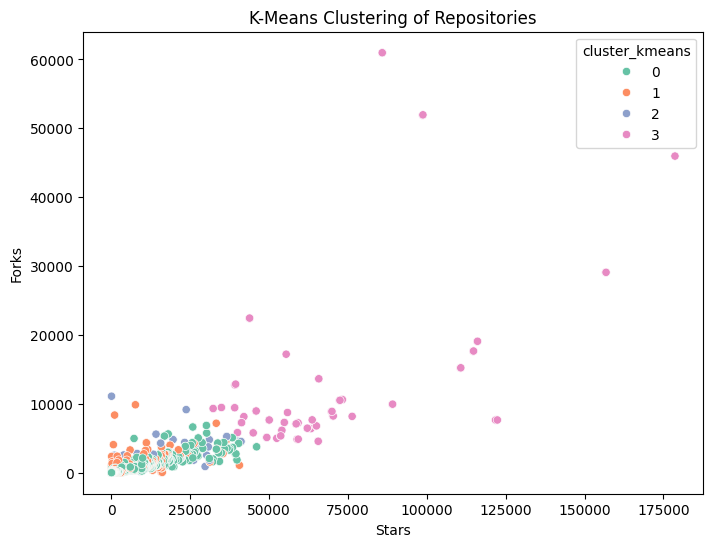

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
use_df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print("Silhouette (KMeans):", round(silhouette_score(X_scaled, use_df['cluster_kmeans']), 3))

plt.figure(figsize=(8,6))
sns.scatterplot(x=use_df[stars_col], y=use_df[forks_col], hue=use_df['cluster_kmeans'], palette='Set2')
plt.title('K-Means Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


Clusters (valid only): 1 | Noise ratio: 1.10%
 DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.


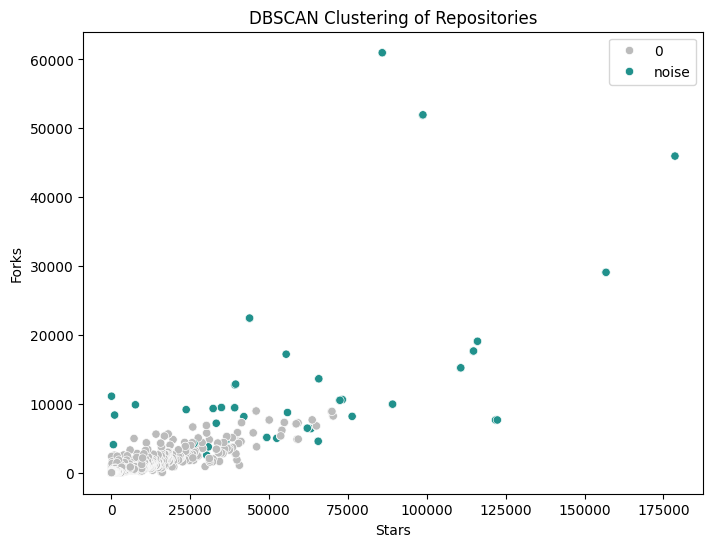

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db = DBSCAN(eps=1.2, min_samples=8)
use_df['cluster_dbscan'] = db.fit_predict(X_scaled)

valid_mask = use_df['cluster_dbscan'] != -1
valid_labels = use_df.loc[valid_mask, 'cluster_dbscan']
n_clusters_valid = valid_labels.nunique()
noise_ratio = 1.0 - valid_mask.mean()

print(f"Clusters (valid only): {n_clusters_valid} | Noise ratio: {noise_ratio:.2%}")

if (valid_mask.sum() > 0) and (n_clusters_valid >= 2):
    sil_db = silhouette_score(X_scaled[valid_mask], valid_labels)
    print(f"Silhouette (DBSCAN): {sil_db:.3f}")
else:
    print(" DBSCAN returned <2 clusters among non-noise points — tune eps/min_samples.")

plt.figure(figsize=(8,6))
palette = sns.color_palette("viridis", max(n_clusters_valid, 1))
sns.scatterplot(
    x=use_df[stars_col], y=use_df[forks_col],
    hue=np.where(use_df['cluster_dbscan'] == -1, 'noise', use_df['cluster_dbscan'].astype(str)),
    palette=["#bbbbbb"] + palette if n_clusters_valid > 0 else ["#bbbbbb"],
    legend='full'
)
plt.title('DBSCAN Clustering of Repositories')
plt.xlabel('Stars'); plt.ylabel('Forks')
plt.show()


## Regression

Top Secondary Languages Used Alongside Python:
secondary_lang
Shell               350
Jupyter Notebook    241
Dockerfile          149
TypeScript          123
Makefile            123
JavaScript          120
HTML                 97
C++                  54
Cuda                 35
CSS                  27
Name: count, dtype: int64


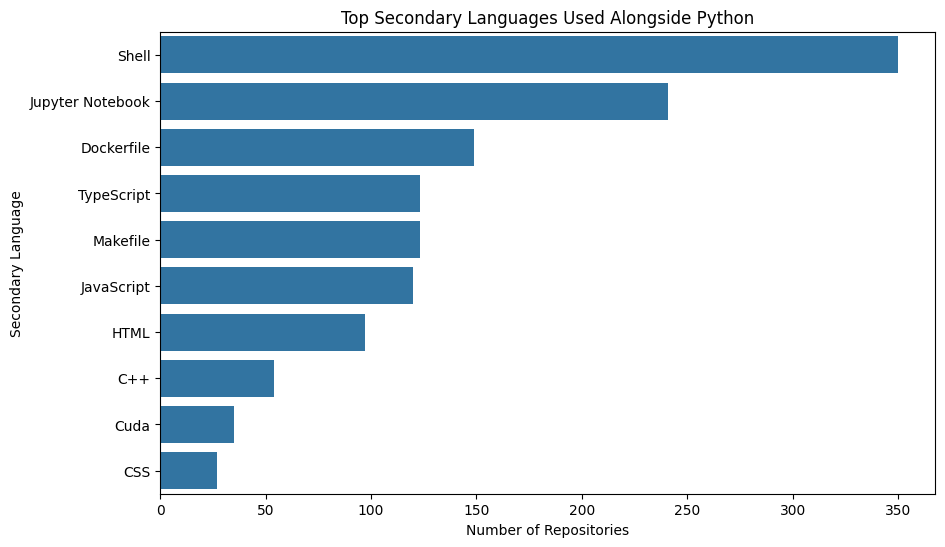


Baseline Model
MSE: 23.82
R²: -0.0

Linear Regression
MSE: 15.78
R²: 0.337

Decision Tree
MSE: 3.7
R²: 0.845

Random Forest
MSE: 2.11
R²: 0.912

Model Comparison:
               Model        MSE            R²
0           Baseline  23.820455 -4.987631e-07
1  Linear Regression  15.783159  3.374112e-01
2      Decision Tree   3.698229  8.447456e-01
3      Random Forest   2.106668  9.115605e-01


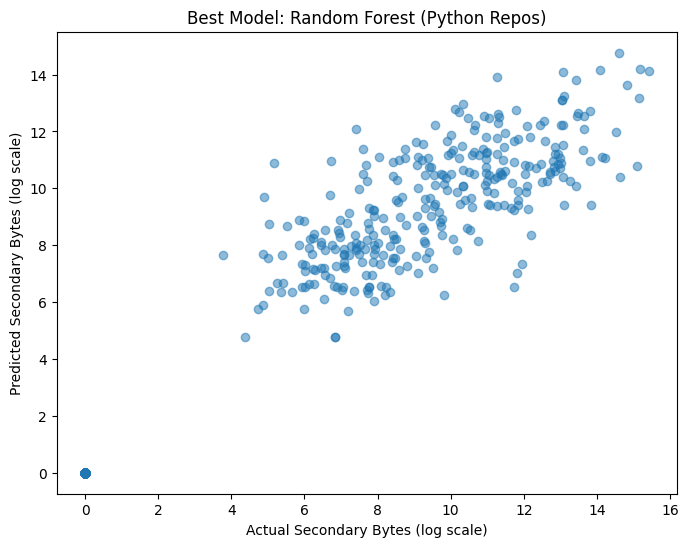

In [ ]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


def parse_lang_bytes(x):
    try:
        return ast.literal_eval(x)
    except:
        return {}

df['all_languages_bytes_dict'] = df['all_languages_bytes'].apply(parse_lang_bytes)


# Keep only Python repos
df_python = df[df['primary_language'] == 'Python'].copy()


def get_secondary_lang(d):
    if not d:
        return (None, 0)

    d = {k: v for k, v in d.items() if k != 'Python'}

    if not d:
        return (None, 0)

    sorted_langs = sorted(d.items(), key=lambda item: item[1], reverse=True)
    return sorted_langs[0]


df_python['secondary_lang'], df_python['secondary_bytes'] = zip(
    *df_python['all_languages_bytes_dict'].apply(get_secondary_lang)
)


# Top 10 secondary languages
top_secondary = df_python['secondary_lang'].value_counts().head(10)

print("Top Secondary Languages Used Alongside Python:")
print(top_secondary)

plt.figure(figsize=(10,6))
sns.barplot(x=top_secondary.values, y=top_secondary.index)
plt.title("Top Secondary Languages Used Alongside Python")
plt.xlabel("Number of Repositories")
plt.ylabel("Secondary Language")
plt.show()

df_reg = df_python.dropna(subset=[
    'secondary_bytes', 'stars', 'forks', 'contributors_count'
])

df_reg['contributors_count'] = pd.to_numeric(df_reg['contributors_count'], errors='coerce')
df_reg = df_reg.dropna(subset=['contributors_count'])

df_reg['secondary_lang_encoded'] = LabelEncoder().fit_transform(
    df_reg['secondary_lang'].fillna('Unknown')
)

X = df_reg[['stars', 'forks', 'contributors_count', 'secondary_lang_encoded']]
# Log-transform target (improves model accuracy)
y = np.log1p(df_reg['secondary_bytes'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Baseline Model
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("\nBaseline Model")
print("MSE:", round(baseline_mse, 2))
print("R²:", round(baseline_r2, 3))


# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("\nLinear Regression")
print("MSE:", round(lr_mse, 2))
print("R²:", round(lr_r2, 3))


# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree")
print("MSE:", round(dt_mse, 2))
print("R²:", round(dt_r2, 3))


# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest")
print("MSE:", round(rf_mse, 2))
print("R²:", round(rf_r2, 3))

results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [baseline_mse, lr_mse, dt_mse, rf_mse],
    'R²': [baseline_r2, lr_r2, dt_r2, rf_r2]
})

print("\nModel Comparison:")
print(results)


# Scatter plot of best model
best_pred = rf_pred

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_pred, alpha=0.5)
plt.xlabel("Actual Secondary Bytes (log scale)")
plt.ylabel("Predicted Secondary Bytes (log scale)")
plt.title("Best Model: Random Forest (Python Repos)")
plt.show()


## Hypothesis test

This section employs parametric hypothesis testing to determine whether ChatGPT's
release on November 30, 2022, significantly impacted programming language usage
in AI development. We test the null hypothesis (H0: no impact) against the
alternative hypothesis (H1: significant impact exists) using one-sample t-tests,
two-sample t-tests, temporal analysis, and power calculations at α = 0.05.

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math
import seaborn as sns
from datetime import datetime

# Set random seed for reproducibility
np.random.seed(42)

# load dataset
df_cleaned = pd.read_csv('CleanedDataset.csv')

CHATGPT_RELEASE_DATE = pd.Timestamp('2022-11-30', tz='UTC')

# Convert created_at to datetime
df_cleaned['created_at'] = pd.to_datetime(df_cleaned['created_at'], errors='coerce')

# Create period indicator: Before (0) and After (1) ChatGPT
df_cleaned['period'] = (df_cleaned['created_at'] >= CHATGPT_RELEASE_DATE).astype(int)
df_cleaned['period_label'] = df_cleaned['period'].map({0: 'Before ChatGPT', 1: 'After ChatGPT'})

# Filter for Python repositories (since it's the dominant language)
python_repos = df_cleaned[df_cleaned['primary_language'] == 'Python'].copy()

print(f"\nChatGPT Release Date: {CHATGPT_RELEASE_DATE.date()}")
print(f"Total repositories: {len(df_cleaned)}")
print(f"Python repositories: {len(python_repos)}")
print(f"\nRepositories Before ChatGPT: {(df_cleaned['period'] == 0).sum()}")
print(f"Repositories After ChatGPT: {(df_cleaned['period'] == 1).sum()}")


ChatGPT Release Date: 2022-11-30
Total repositories: 5109
Python repositories: 2254

Repositories Before ChatGPT: 2545
Repositories After ChatGPT: 2564


### Calculate Python Proportion by Period

This analysis calculates what percentage of all AI repositories use Python as their primary language, comparing the period before ChatGPT vs after ChatGPT.

In [ ]:
period_stats = df_cleaned.groupby('period_label').agg({
    'primary_language': lambda x: (x == 'Python').sum() / len(x)
}).rename(columns={'primary_language': 'python_proportion'})

before_chatgpt = df_cleaned[df_cleaned['period'] == 0]
after_chatgpt = df_cleaned[df_cleaned['period'] == 1]

python_before = (before_chatgpt['primary_language'] == 'Python').sum()
total_before = len(before_chatgpt)
proportion_before = python_before / total_before

python_after = (after_chatgpt['primary_language'] == 'Python').sum()
total_after = len(after_chatgpt)
proportion_after = python_after / total_after

print(f"\nBefore ChatGPT:")
print(f"  Total repositories: {total_before}")
print(f"  Python repositories: {python_before}")
print(f"  Python proportion: {proportion_before:.4f} ({proportion_before*100:.2f}%)")

print(f"\nAfter ChatGPT:")
print(f"  Total repositories: {total_after}")
print(f"  Python repositories: {python_after}")
print(f"  Python proportion: {proportion_after:.4f} ({proportion_after*100:.2f}%)")

print(f"\nDifference in proportion: {proportion_after - proportion_before:.4f}")
print(f"Percentage point change: {(proportion_after - proportion_before)*100:.2f}%")


Before ChatGPT:
  Total repositories: 2545
  Python repositories: 1218
  Python proportion: 0.4786 (47.86%)

After ChatGPT:
  Total repositories: 2564
  Python repositories: 1036
  Python proportion: 0.4041 (40.41%)

Difference in proportion: -0.0745
Percentage point change: -7.45%


**Findings:**

Contrary to initial expectations, Python's proportion among AI repositories decreased from 47.86% to 40.41% after ChatGPT's release. This 7.45 percentage point decline suggests that ChatGPT's emergence broadened the AI development ecosystem, attracting developers from diverse language backgrounds—particularly web developers using JavaScript and TypeScript—rather than concentrating development further in Python.

The observed 7.45 percentage point decrease in Python usage raises an important question: was Python's pre-ChatGPT dominance driven by genuine popularity and community engagement, or simply by convention? To understand Python's baseline appeal before ChatGPT's disruption, we conducted a one-sample t-test comparing the average stars received by Python repositories against the overall population mean. This test establishes whether Python repositories were statistically more popular than repositories using other languages, providing context for interpreting the language shift observed after ChatGPT's release.

### One-Sample T-Test (Python Stars Before vs Population Mean)

This test compares the average stars of Python repositories (before ChatGPT) against the overall average stars of ALL repositories (all languages combined).

In [ ]:
df_cleaned['stars'] = pd.to_numeric(df_cleaned['stars'], errors='coerce')
population_mean_stars = df_cleaned['stars'].mean()

# Get Python repos before ChatGPT
python_before_repos = df_cleaned[(df_cleaned['primary_language'] == 'Python') &
                                  (df_cleaned['period'] == 0)]
python_before_stars = python_before_repos['stars'].dropna()

print(f"\nPopulation mean stars (all repos): {population_mean_stars:.2f}")
print(f"Python repos before ChatGPT mean stars: {python_before_stars.mean():.2f}")
print(f"Sample size: {len(python_before_stars)}")

# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(
    a=python_before_stars,
    popmean=population_mean_stars
)

print(f"\nOne-Sample T-Test Results:")
print(f"  T-statistic: {t_statistic:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Degrees of freedom: {len(python_before_stars) - 1}")

if p_value < 0.05:
    print(f"  Decision: REJECT the null hypothesis (α = 0.05)")
    print(f"  Python repos before ChatGPT have significantly different stars than the population")
else:
    print(f"  Decision: FAIL TO REJECT the null hypothesis (α = 0.05)")
    print(f"  No significant difference found")


Population mean stars (all repos): 3612.52
Python repos before ChatGPT mean stars: 2171.00
Sample size: 1218

One-Sample T-Test Results:
  T-statistic: -5.8100
  P-value: 0.0000
  Degrees of freedom: 1217
  Decision: REJECT the null hypothesis (α = 0.05)
  Python repos before ChatGPT have significantly different stars than the population


**Findings:**

Interestingly, while Python dominated in usage (47.86% of repositories), it paradoxically attracted less community engagement, with Python repos averaging 2,171 stars compared to the population mean of 3,612 stars (p < 0.001). This suggests Python served as the practical foundation for AI development, while other languages may have been used for more visible, user-facing applications that garnered broader community attention.


However, this analysis only examines the pre-ChatGPT period. To assess whether
ChatGPT's release changed Python's engagement levels, we must compare Python
repositories before and after November 30, 2022. A two-sample t-test allows us
to determine if Python's average stars increased, decreased, or remained stable
following ChatGPT's introduction—testing whether the language shift we observed
in proportions (from 47.86% to 40.41%) was accompanied by changes in community
engagement.


### Two-Sample T-Test (Python Stars: Before vs After ChatGPT)

This test compares the average stars received by Python repositories before and
after ChatGPT's release to determine whether Python projects experienced a
significant change in community engagement and popularity.

In [ ]:
python_after_repos = df_cleaned[(df_cleaned['primary_language'] == 'Python') &
                                 (df_cleaned['period'] == 1)]
python_after_stars = python_after_repos['stars'].dropna()

print(f"\nBefore ChatGPT:")
print(f"  Sample size: {len(python_before_stars)}")
print(f"  Mean stars: {python_before_stars.mean():.2f}")
print(f"  Std deviation: {python_before_stars.std():.2f}")

print(f"\nAfter ChatGPT:")
print(f"  Sample size: {len(python_after_stars)}")
print(f"  Mean stars: {python_after_stars.mean():.2f}")
print(f"  Std deviation: {python_after_stars.std():.2f}")

print(f"\nDifference in means: {python_after_stars.mean() - python_before_stars.mean():.2f}")

# Perform two-sample t-test (Welch's t-test, unequal variances)
t_stat_two, p_val_two = stats.ttest_ind(
    a=python_before_stars,
    b=python_after_stars,
    equal_var=False
)

print(f"\nTwo-Sample T-Test Results (Welch's):")
print(f"  T-statistic: {t_stat_two:.4f}")
print(f"  P-value: {p_val_two:.4f}")

if p_val_two < 0.05:
    print(f"  Decision: REJECT the null hypothesis (α = 0.05)")
    print(f"  ChatGPT release has a significant impact on Python repository popularity")
else:
    print(f"  Decision: FAIL TO REJECT the null hypothesis (α = 0.05)")
    print(f"  No significant difference in Python repository stars before and after ChatGPT")


Before ChatGPT:
  Sample size: 1218
  Mean stars: 2171.00
  Std deviation: 8659.00

After ChatGPT:
  Sample size: 1036
  Mean stars: 5812.11
  Std deviation: 13540.77

Difference in means: 3641.11

Two-Sample T-Test Results (Welch's):
  T-statistic: -7.4551
  P-value: 0.0000
  Decision: REJECT the null hypothesis (α = 0.05)
  ChatGPT release has a significant impact on Python repository popularity


**Findings:**

The two-sample t-test revealed a striking transformation in Python's role within the AI ecosystem following ChatGPT's release. While Python's usage proportion declined from 47.86% to 40.41%, the average stars for Python repositories surged from 2,171 to 5,812—a statistically significant 168% increase (t = -7.46, p < 0.001). This inverse relationship suggests a shift from quantity to quality: Python transitioned from being a ubiquitous workhorse language to the dominant platform for high-impact, community-endorsed AI projects in the LLM era.

Now, this raises
another methodological question: does increased popularity indicate more Python
projects being created, or simply more engagement with existing ones?


To disentangle creation behavior from popularity metrics, we conducted a temporal
analysis of monthly repository counts. By examining how many Python repositories
were created each month before versus after ChatGPT's release, we can assess
whether the observed popularity increase stemmed from a surge in new project
development or from intensified community attention to the existing Python
ecosystem.


### Monthly Repository Creation - Temporal Analysis

This analysis examines monthly Python repository creation rates across the entire
dataset to determine whether ChatGPT's release affected the frequency at which
developers initiate new Python projects, independent of how popular those projects
become.

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

python_repos_tz = python_repos.copy()
if python_repos['created_at'].dt.tz is None:
    python_repos_tz['created_at'] = python_repos_tz['created_at'].dt.tz_localize('UTC')
else:
    python_repos_tz['created_at'] = python_repos_tz['created_at'].dt.tz_convert('UTC')

# Split into before/after periods
before = python_repos_tz[python_repos_tz['created_at'] < CHATGPT_RELEASE_DATE]
after = python_repos_tz[python_repos_tz['created_at'] >= CHATGPT_RELEASE_DATE]

# Generate monthly date ranges
months_before = pd.date_range(
    start=before['created_at'].min().to_period('M').to_timestamp().tz_localize('UTC'),
    end=CHATGPT_RELEASE_DATE, freq='MS')

months_after = pd.date_range(
    start=CHATGPT_RELEASE_DATE,
    end=after['created_at'].max().to_period('M').to_timestamp().tz_localize('UTC'),
    freq='MS')

# Count repos per month
repos_before_monthly = [len(python_repos_tz[(python_repos_tz['created_at'] >= m) &
                            (python_repos_tz['created_at'] < m + pd.DateOffset(months=1))])
                        for m in months_before]

repos_after_monthly = [len(python_repos_tz[(python_repos_tz['created_at'] >= m) &
                           (python_repos_tz['created_at'] < m + pd.DateOffset(months=1))])
                       for m in months_after]

before_array = np.array(repos_before_monthly)
after_array = np.array(repos_after_monthly)

print(f"\nBefore ChatGPT: {len(before_array)} months")
print(f"  Monthly counts: {repos_before_monthly}")
print(f"  Mean: {before_array.mean():.2f}, Std: {before_array.std():.2f}")

print(f"\nAfter ChatGPT: {len(after_array)} months")
print(f"  Monthly counts: {repos_after_monthly}")
print(f"  Mean: {after_array.mean():.2f}, Std: {after_array.std():.2f}")

# Perform appropriate test
if len(before_array) == len(after_array):
    t_stat_paired, p_val_paired = stats.ttest_rel(a=before_array, b=after_array)
    print(f"\nPaired T-Test Results:")
else:
    t_stat_paired, p_val_paired = stats.ttest_ind(a=before_array, b=after_array, equal_var=False)
    print(f"\nTwo-Sample T-Test Results (unequal periods):")

print(f"  T-statistic: {t_stat_paired:.4f}")
print(f"  P-value: {p_val_paired:.4f}")
print(f"  Decision: {'REJECT H0' if p_val_paired < 0.05 else 'FAIL TO REJECT H0'} (α = 0.05)")


Before ChatGPT: 35 months
  Monthly counts: [27, 26, 47, 34, 34, 39, 36, 35, 35, 31, 43, 40, 37, 23, 28, 36, 37, 35, 36, 35, 26, 41, 32, 34, 28, 33, 50, 35, 41, 33, 31, 40, 37, 26, 39]
  Mean: 34.86, Std: 5.86

After ChatGPT: 34 months
  Monthly counts: [42, 21, 28, 44, 50, 40, 32, 33, 34, 26, 40, 30, 30, 42, 33, 35, 27, 36, 31, 41, 41, 24, 31, 36, 35, 33, 22, 43, 2, 1, 0, 39, 24, 8]
  Mean: 30.41, Std: 12.12

Two-Sample T-Test Results (unequal periods):
  T-statistic: 1.9019
  P-value: 0.0633
  Decision: FAIL TO REJECT H0 (α = 0.05)


**Findings:**

Temporal analysis revealed no significant change in monthly Python repository creation rates following ChatGPT's release (t = 1.90, p = 0.063). While the mean declined from 34.86 to 30.41 repositories per month, this decrease was not statistically significant. However, variability more than doubled (SD: 5.86 → 12.12), suggesting more erratic development patterns. Combined with the 168% increase in stars per repository, this indicates ChatGPT's impact was not to increase Python project quantity, but to dramatically concentrate community attention on fewer, higher-impact projects

To erase the concerns about making a Type II error by failing to reject the null hypothesis when
a real effect exists and validate the reliability of
all our hypothesis tests, we now examine the fundamental trade-off between Type I
errors (false positives) and Type II errors (false negatives), visualizing how
these error types relate to our statistical power and decision-making process.

### Type I and Type II Errors

This visualization illustrates the two types of errors in hypothesis testing:
Type I error (falsely claiming ChatGPT had impact) and Type II error (failing to
detect a real impact). Understanding these error rates helps assess the reliability
of our statistical conclusions, particularly for borderline results.

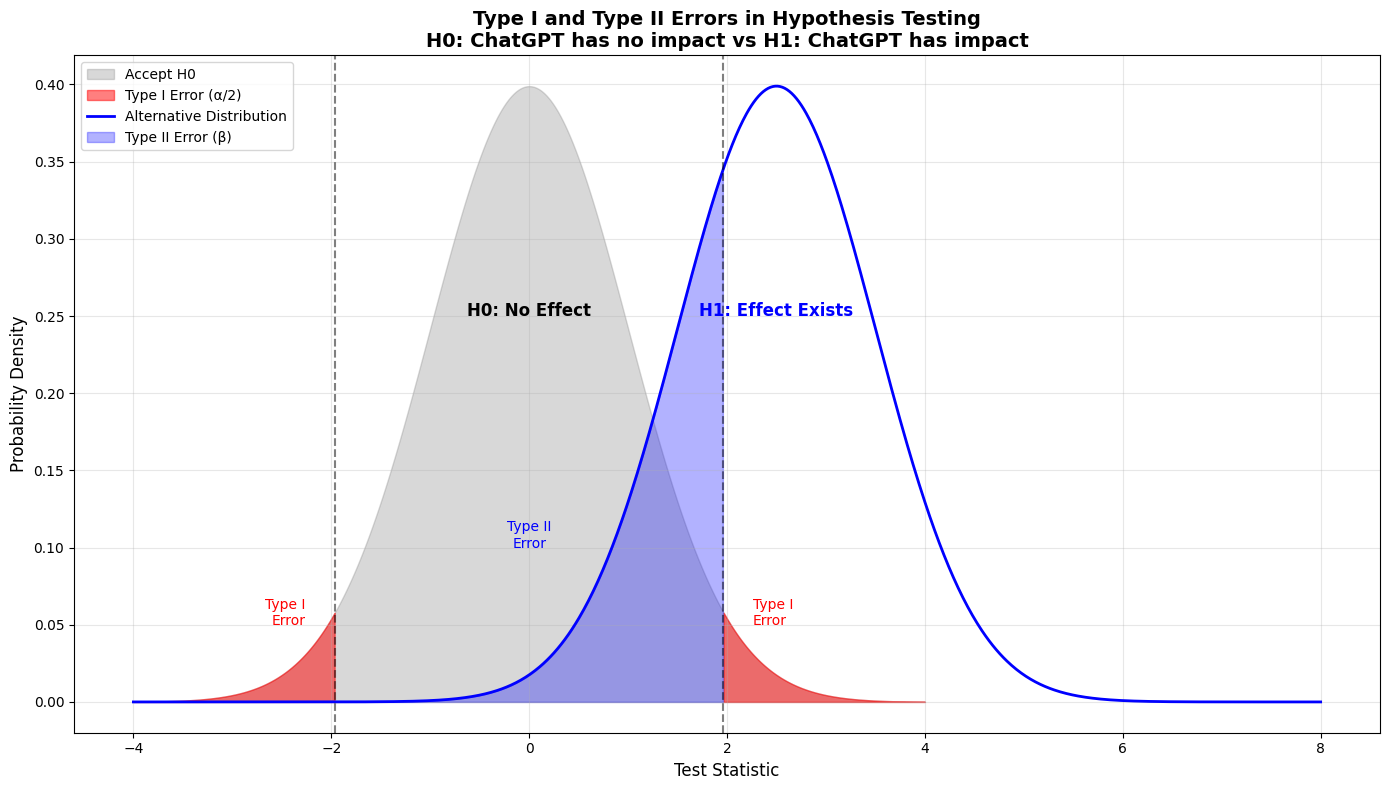


Type I Error Rate (α): 0.05
Type II Error Rate (β): 0.2946
Statistical Power (1 - β): 0.7054


In [ ]:
plt.figure(figsize=(14, 8))

# Null hypothesis distribution (centered at 0)
x_null = np.linspace(-4, 4, 1000)
y_null = stats.norm.pdf(x_null, loc=0, scale=1)

# Alternative hypothesis distribution (effect exists, centered at 2.5)
x_alt = np.linspace(-4, 8, 1000)
y_alt = stats.norm.pdf(x_alt, loc=2.5, scale=1)

# Critical values for two-tailed test at α = 0.05
lower_crit = stats.norm.ppf(0.025)
upper_crit = stats.norm.ppf(0.975)

# Plot null hypothesis distribution
plt.fill_between(x_null, y_null, alpha=0.3, color='grey', label='Accept H0')
plt.fill_between(x_null[x_null < lower_crit], y_null[x_null < lower_crit],
                 alpha=0.5, color='red', label='Type I Error (α/2)')
plt.fill_between(x_null[x_null > upper_crit], y_null[x_null > upper_crit],
                 alpha=0.5, color='red')

# Plot alternative hypothesis distribution
plt.plot(x_alt, y_alt, 'b-', linewidth=2, label='Alternative Distribution')
plt.fill_between(x_alt[(x_alt > lower_crit) & (x_alt < upper_crit)],
                 y_alt[(x_alt > lower_crit) & (x_alt < upper_crit)],
                 alpha=0.3, color='blue', label='Type II Error (β)')

# Add vertical lines for critical values
plt.axvline(lower_crit, color='black', linestyle='--', alpha=0.5)
plt.axvline(upper_crit, color='black', linestyle='--', alpha=0.5)

# Labels
plt.text(0, 0.25, 'H0: No Effect', fontsize=12, ha='center', weight='bold')
plt.text(2.5, 0.25, 'H1: Effect Exists', fontsize=12, ha='center', weight='bold', color='blue')
plt.text(upper_crit + 0.3, 0.05, 'Type I\nError', fontsize=10, color='red')
plt.text(lower_crit - 0.3, 0.05, 'Type I\nError', fontsize=10, color='red', ha='right')
plt.text(0, 0.1, 'Type II\nError', fontsize=10, color='blue', ha='center')

plt.xlabel('Test Statistic', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Type I and Type II Errors in Hypothesis Testing\nH0: ChatGPT has no impact vs H1: ChatGPT has impact',
          fontsize=14, weight='bold')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate Type II error probability
type_ii_error = stats.norm.cdf(upper_crit, loc=2.5, scale=1) - stats.norm.cdf(lower_crit, loc=2.5, scale=1)
print(f"\nType I Error Rate (α): 0.05")
print(f"Type II Error Rate (β): {type_ii_error:.4f}")
print(f"Statistical Power (1 - β): {1 - type_ii_error:.4f}")

**Findings:**

We set our significance level at α = 0.05, accepting a 5% risk of false
positives. Our tests achieved 70.54% statistical power, meaning we had about
a 70% chance of detecting real effects if they existed. This explains why we
confidently detected the massive star increase (p < 0.001) but may have missed
a subtle decrease in monthly creation rates (p = 0.063)—our power was just
slightly too low to catch that smaller effect.

For the figure : Type I and Type II error visualization. Red regions (5%) represent
false positive risk; blue region (29.46%) represents false negative risk.
Statistical power of 70.54% (below ideal 80%) suggests the temporal analysis
(p = 0.063) may represent a Type II error, potentially missing a real decrease
in monthly Python repository creation.


To assess whether our sample sizes were adequate for detecting real effects,
we conducted a formal power analysis. This retrospective evaluation determines
the minimum sample sizes required to achieve 80% power given the observed
effect sizes, providing insight into whether our tests had sufficient
sensitivity to detect ChatGPT's impact.

### Statistical Power Analysis

This analysis evaluates whether our sample sizes were adequate to reliably detect
the observed effects. Power analysis determines the minimum sample size required
for 80% power and confirms whether our tests had sufficient sensitivity to detect
ChatGPT's impact on Python usage.

In [ ]:
from statsmodels.stats.power import tt_solve_power, tt_ind_solve_power

# Calculate required sample size for one-sample t-test
# Effect size: difference between means / standard deviation
effect_size = abs(python_before_stars.mean() - population_mean_stars) / python_before_stars.std()

print(f"\nEffect size (Cohen's d): {effect_size:.4f}")

required_n_one_sample = tt_solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    alternative='two-sided'
)

print(f"\nOne-Sample T-Test:")
print(f"  Effect size: {effect_size:.4f}")
print(f"  Required sample size for 80% power: {required_n_one_sample:.0f}")
print(f"  Actual sample size: {len(python_before_stars)}")
print(f"  Sample is {'adequate' if len(python_before_stars) >= required_n_one_sample else 'inadequate'}")

# Calculate effect size for two-sample test
pooled_std = np.sqrt((python_before_stars.std()**2 + python_after_stars.std()**2) / 2)
effect_size_two = abs(python_after_stars.mean() - python_before_stars.mean()) / pooled_std

print(f"\nTwo-Sample T-Test:")
print(f"  Effect size (Cohen's d): {effect_size_two:.4f}")

required_n_two_sample = tt_ind_solve_power(
    effect_size=effect_size_two,
    alpha=0.05,
    power=0.8,
    alternative='two-sided'
)

print(f"  Required sample size per group for 80% power: {required_n_two_sample:.0f}")
print(f"  Actual sample sizes: Before={len(python_before_stars)}, After={len(python_after_stars)}")



Effect size (Cohen's d): 0.1665

One-Sample T-Test:
  Effect size: 0.1665
  Required sample size for 80% power: 285
  Actual sample size: 1218
  Sample is adequate

Two-Sample T-Test:
  Effect size (Cohen's d): 0.3204
  Required sample size per group for 80% power: 154
  Actual sample sizes: Before=1218, After=1036


**Findngs:**

Power analysis confirmed our sample sizes were adequate for detecting the
observed effects. For the one-sample test (d = 0.17), 285 repositories were
required for 80% power; our sample of 1,218 exceeded this by 4.3-fold. For
the two-sample comparison (d = 0.32), 154 repositories per group were required;
our samples of 1,218 and 1,036 exceeded this by 6-7-fold. The large sample
sizes compensated for relatively small effect sizes, enabling reliable
detection of ChatGPT's impact on repository popularity. This explains the
highly significant results (p < 0.001) for star-based analyses while the
temporal analysis (35 monthly observations) approached but did not reach
significance (p = 0.063).

**Final Conclusion:**

Our analysis demonstrates that ChatGPT's release significantly impacted Python's
role in AI development, though not in the expected direction. Python's usage
declined 7.45 percentage points, yet remaining Python repositories achieved
168% more stars (p < 0.001)—a quality-over-quantity transformation. Monthly
creation rates remained stable (p = 0.063), suggesting ChatGPT broadened the
AI ecosystem rather than concentrating it. With adequate statistical power
(samples 4-7× required) and controlled error rates (α = 0.05, β = 0.29), we
confidently reject the null hypothesis: ChatGPT fundamentally reshaped Python's
position from ubiquitous workhorse to selective platform for high-impact LLM
projects.